### Optuna is an advanced hyperparameter optimization library used to automatically find the best hyperparameters efficiently.

The biggest difference from:

1. Grid Search
2. Random Search

is:

Optuna learns from previous trials

and intelligently selects the next combination.

#### Optuna's Idea

Optuna says:

- Why search blindly?
- Let's learn from previous results and search smarter.

#### Main Intuition Behind Optuna
| Trial | max_depth | Accuracy |
| ----- | --------- | -------- |
| 1     | 2         | 70%      |
| 2     | 5         | 85%      |
| 3     | 20        | 60%      |
Optuna learns:

max_depth around 5 looks promising
So next trials focus near:

4,5,6,7

instead of wasting time on bad regions.

## How Optuna Selects Next Combination
Optuna mainly uses:

**Bayesian Optimization**

#### STEP 1 — Try Random Parameters Initially
| Trial | Parameters  | Accuracy |
| ----- | ----------- | -------- |
| 1     | max_depth=2 | 70%      |
| 2     | max_depth=8 | 82%      |
| 3     | max_depth=5 | 88%      |
#### STEP 2 — Learn Parameter Behavior

Optuna builds an internal understanding:

Which regions give good performance
#### STEP 3 — Predict Promising Areas

Optuna predicts:

Parameters near good regions may work better
#### STEP 4 — Next Trial Focuses Near Best Areas

Instead of random guessing:

Smart guided search

### Important Optuna Terms
| Term               | Meaning                 |
| ------------------ | ----------------------- |
| Trial              | One experiment          |
| Study              | Collection of trials    |
| Objective Function | Function to optimize    |
| Sampler            | Chooses next parameters |


In [1]:
!pip install optuna

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [colorlog]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   ----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
import pandas as pd
import optuna

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier

In [3]:
# step -1
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)

y = data.target

In [6]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [4]:
# step-2
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)


#### 3. Create Objective Function

- This is the heart of Optuna.

In [10]:
def objective(trial):

    n_estimators = trial.suggest_int(
        'n_estimators',
        50,
        300
    )

    max_depth = trial.suggest_int(
        'max_depth',
        2,
        20
    )

    min_samples_split = trial.suggest_int(
        'min_samples_split',
        2,
        10
    )

    model = RandomForestClassifier(

        n_estimators=n_estimators,

        max_depth=max_depth,

        min_samples_split=min_samples_split,

        random_state=42
    )

    score = cross_val_score(

        model,

        X_train,

        y_train,

        cv=5,

        scoring='accuracy'
    ).mean()

    return score

In [20]:
import optuna

def objective_sample(trial):

    x = trial.suggest_int("x", 1, 10)

    print("Suggested Value:", x)

    return x

study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=5)

[I 2026-05-27 12:25:06,907] A new study created in memory with name: no-name-4cdad743-c185-4ca3-b168-d3a153607af0
[I 2026-05-27 12:25:08,482] Trial 0 finished with value: 0.9538461538461538 and parameters: {'n_estimators': 55, 'max_depth': 18, 'min_samples_split': 6}. Best is trial 0 with value: 0.9538461538461538.
[I 2026-05-27 12:25:12,232] Trial 1 finished with value: 0.9626373626373625 and parameters: {'n_estimators': 203, 'max_depth': 12, 'min_samples_split': 2}. Best is trial 1 with value: 0.9626373626373625.
[I 2026-05-27 12:25:13,835] Trial 2 finished with value: 0.9494505494505494 and parameters: {'n_estimators': 107, 'max_depth': 18, 'min_samples_split': 10}. Best is trial 1 with value: 0.9626373626373625.
[I 2026-05-27 12:25:16,749] Trial 3 finished with value: 0.956043956043956 and parameters: {'n_estimators': 204, 'max_depth': 5, 'min_samples_split': 3}. Best is trial 1 with value: 0.9626373626373625.
[I 2026-05-27 12:25:18,271] Trial 4 finished with value: 0.9494505494505

**`suggest_int()`** does not randomly pick values forever.
Initially it explores randomly, then gradually learns which values give better results.
- Optuna’s **suggest_*()** functions define the search space, and Optuna intelligently searches inside that space.

#### Other Similar Functions in Optuna
| Function                | Purpose            |
| ----------------------- | ------------------ |
| `suggest_int()`         | Integer values     |
| `suggest_float()`       | Decimal values     |
| `suggest_categorical()` | Category selection |
| `suggest_loguniform()`  | Log-scale values   |


#### 4. Create Study

In [11]:
study = optuna.create_study(

    direction='maximize'
)

[I 2026-05-24 20:49:16,551] A new study created in memory with name: no-name-eadc4845-aee2-4089-946b-100217287acd


#### 5. Start Optimization

In [12]:
study.optimize(

    objective,

    n_trials=30
)

[I 2026-05-24 20:49:59,657] Trial 0 finished with value: 0.956043956043956 and parameters: {'n_estimators': 289, 'max_depth': 8, 'min_samples_split': 4}. Best is trial 0 with value: 0.956043956043956.
[I 2026-05-24 20:50:03,494] Trial 1 finished with value: 0.9516483516483516 and parameters: {'n_estimators': 164, 'max_depth': 9, 'min_samples_split': 8}. Best is trial 0 with value: 0.956043956043956.
[I 2026-05-24 20:50:06,287] Trial 2 finished with value: 0.9538461538461538 and parameters: {'n_estimators': 117, 'max_depth': 6, 'min_samples_split': 10}. Best is trial 0 with value: 0.956043956043956.
[I 2026-05-24 20:50:12,807] Trial 3 finished with value: 0.9604395604395604 and parameters: {'n_estimators': 274, 'max_depth': 15, 'min_samples_split': 2}. Best is trial 3 with value: 0.9604395604395604.
[I 2026-05-24 20:50:16,881] Trial 4 finished with value: 0.9626373626373625 and parameters: {'n_estimators': 173, 'max_depth': 13, 'min_samples_split': 3}. Best is trial 4 with value: 0.9626

In [13]:
print("Best Parameters:\n")

print(study.best_params)

Best Parameters:

{'n_estimators': 150, 'max_depth': 13, 'min_samples_split': 3}


In [14]:
print("Best Accuracy:\n")

print(study.best_value)

Best Accuracy:

0.9648351648351647


C:\Users\DELL\AppData\Local\Temp\ipykernel_22908\3395742928.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


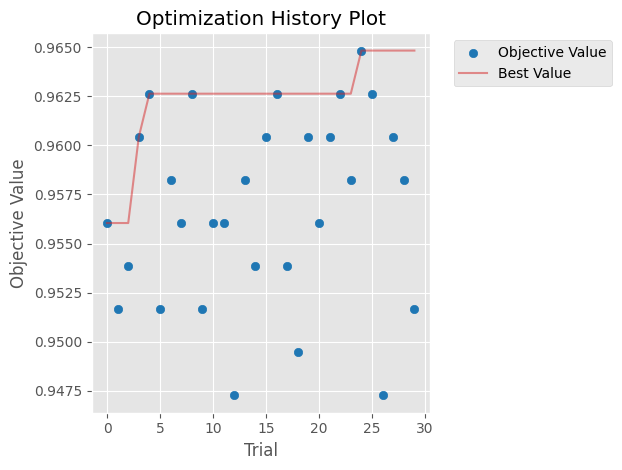

In [17]:
import matplotlib.pyplot as plt
optuna.visualization.matplotlib.plot_optimization_history(study)

plt.show()

**1. Grid Search is brute force.
2. Random Search is random guessing.
3. Optuna is intelligent searching.**

C:\Users\DELL\AppData\Local\Temp\ipykernel_22908\2428919624.py:1: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_parallel_coordinate(study, params=['n_estimators','max_depth','min_samples_split'])


<Axes: title={'center': 'Parallel Coordinate Plot'}>

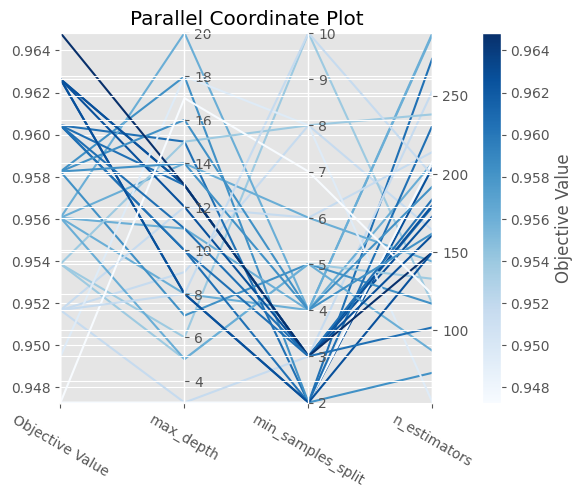

In [19]:
optuna.visualization.matplotlib.plot_parallel_coordinate(study, params=['n_estimators','max_depth','min_samples_split'])